In [30]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [32]:
df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])

In [33]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [34]:
df.dropna(inplace=True)
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [35]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [36]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [38]:
clf = DecisionTreeClassifier()

In [39]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [40]:
accuracy_score(y_test,y_pred)

0.6433566433566433

In [41]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6303012519561815)

In [42]:
# by creating bins
# Bins → intervals/groups, Discretizer → converting continuous values into discrete values.
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
# strategy='quantile'=most important part.=> means:Create bins such that each bin has roughly the same number of observations.

In [43]:
trf =ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [44]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.fit_transform(X_test)

In [45]:
trf.named_transformers_['first'].bin_edges_

array([array([ 1.,  9., 16., 17., 20., 21., 24., 26., 28., 30., 34., 36., 39.,
              44., 52., 62.])                                                 ],
      dtype=object)

In [46]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.125 ,   7.775 ,   7.925 ,   8.05  ,   9.5   ,
               10.5   ,  13.    ,  17.8   ,  22.525 ,  26.3875,  31.275 ,
               39.    ,  53.1   ,  79.65  , 512.3292])                   ],
      dtype=object)

In [49]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [51]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                              bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                               bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [53]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
148,36.5,10.0,26.000,9.0,"(36.0, 39.0]","(22.525, 26.388]"
153,40.5,11.0,14.500,7.0,"(39.0, 44.0]","(13.0, 17.8]"
603,44.0,12.0,8.050,3.0,"(39.0, 44.0]","(7.925, 8.05]"
544,50.0,13.0,106.425,13.0,"(44.0, 52.0]","(79.65, 512.329]"
654,18.0,2.0,6.750,0.0,"(17.0, 20.0]","(0.0, 7.125]"


In [54]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [55]:
accuracy_score(y_test,y_pred2)

0.6573426573426573

In [56]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.63589593114241)

In [70]:
def descretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    X_trf= trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Age Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Fare Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6386737089201877


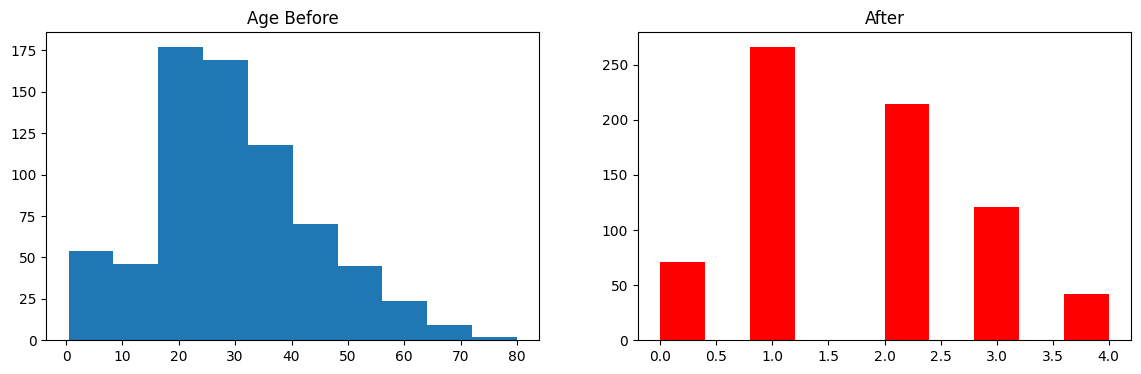

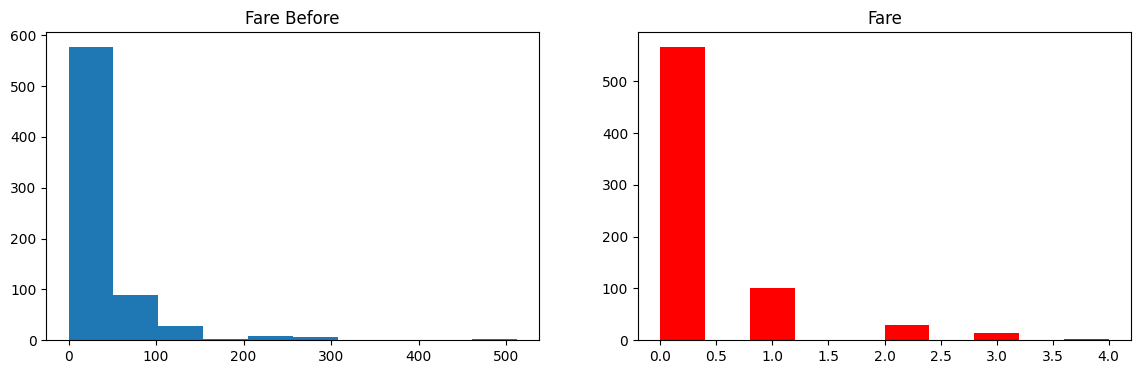

In [71]:
descretize(5,'kmeans')